# 1. Import das bibliotecas necessárias

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats


# 2. Carregamento dos dados

### Sobre o dataset

#### Contexto
Uma empresa fictícia de telecomunicações que forneceu serviços de telefonia fixa e internet para 7.043 clientes na Califórnia no terceiro trimestre.

##### Esquema de variáveis (conforme o kaggle)

- ID do cliente : Um ID exclusivo que identifica cada cliente.

- Contagem : Um valor usado em relatórios/painéis para somar o número de clientes em um conjunto filtrado.

- País : O país de residência principal do cliente.

- Estado : O estado da residência principal do cliente.

- Cidade : A cidade da residência principal do cliente.

- CEP : O CEP da residência principal do cliente.

- Lat Long : A combinação da latitude e longitude da residência principal do cliente.

- Latitude : A latitude da residência principal do cliente.

- Longitude : A longitude da residência principal do cliente.

- Gênero : O gênero do cliente: Masculino, Feminino

- Idoso : Indica se o cliente tem 65 anos ou mais: Sim, Não

- Parceiro : Indique se o cliente tem um parceiro: Sim, Não

- Dependentes : Indica se o cliente mora com algum dependente: Sim, Não. Dependentes podem ser filhos, pais, avós, etc.

- Tempo de permanência no relacionamento : Indica o número total de meses que o cliente permaneceu com a empresa até o final do trimestre especificado acima.

- Serviço Telefônico : Indica se o cliente possui assinatura de serviço de telefonia fixa com a empresa: Sim, Não

- Linhas Múltiplas : Indica se o cliente possui várias linhas telefônicas com a empresa: Sim, Não

- Serviço de Internet : Indica se o cliente possui assinatura de serviço de Internet com a empresa: Não, DSL, Fibra Óptica, Cabo.

- Segurança online : Indica se o cliente subscreve um serviço adicional de segurança online fornecido pela empresa: Sim, Não

- Backup online : Indica se o cliente subscreve um serviço adicional de backup online fornecido pela empresa: Sim, Não

- Proteção do dispositivo : Indica se o cliente subscreveu um plano adicional de proteção para o seu equipamento de Internet fornecido pela empresa: Sim, Não

- Suporte técnico : Indica se o cliente subscreveu um plano adicional de suporte técnico da empresa com tempos de espera reduzidos: Sim, Não

- Streaming de TV : Indica se o cliente utiliza seu serviço de internet para assistir a programas de televisão de um provedor terceirizado: Sim, Não. A empresa não cobra nenhuma taxa adicional por este serviço.

- Streaming de filmes : Indica se o cliente utiliza seu serviço de internet para assistir a filmes de um provedor terceirizado: Sim, Não. A empresa não cobra nenhuma taxa adicional por este serviço.

- Contrato : Indica o tipo de contrato atual do cliente: Mensal, Anual ou Bienal.

- Fatura eletrônica : Indica se o cliente optou pela fatura eletrônica: Sim, Não

- Método de pagamento : Indica como o cliente pagará sua conta: Débito bancário, Cartão de crédito, Cheque enviado pelo correio

- Cobrança mensal : Indica o valor total cobrado mensalmente pelo cliente por todos os serviços prestados pela empresa.

- Total de Cobranças : Indica o total de cobranças do cliente, calculado até o final do trimestre especificado acima.

- Rótulo de Churn : Sim = o cliente deixou a empresa neste trimestre. Não = o cliente permaneceu com a empresa. Diretamente relacionado ao Valor do Churn.

- Valor de Churn : 1 = o cliente deixou a empresa neste trimestre. 0 = o cliente permaneceu com a empresa. Diretamente relacionado ao Rótulo de Churn.

- Churn Score : Um valor de 0 a 100 calculado usando a ferramenta preditiva IBM SPSS Modeler. O modelo incorpora múltiplos fatores conhecidos por causarem churn. Quanto maior a pontuação, maior a probabilidade de o cliente cancelar o serviço.

- CLTV : Valor do Tempo de Vida do Cliente. O CLTV previsto é calculado usando fórmulas corporativas e dados existentes. Quanto maior o valor, mais valioso o cliente. Clientes de alto valor devem ser monitorados quanto à possibilidade de cancelamento (churn).

- Motivo do Cancelamento : A razão específica pela qual um cliente deixou a empresa. Diretamente relacionado à Categoria de Cancelamento.

In [16]:
# Carregando o dataset para o repositório

path = '../data/raw/Telco_customer_churn.xlsx'

df = pd.read_excel(path)

In [17]:
df.rename(columns={
            'CustomerID': 'customer_id',
            'Count': 'count',	
            'Country': 'country',	
            'State': 'state',
            'City': 'city',
            'Zip Code': 'zip_code',
            'Lat Long': 'lat_long',
            'Latitude': 'latitude',
            'Longitude': 'longitude',	
            'Gender': 'gender',
            'Senior Citizen': 'senior_citizen',
            'Partner': 'partner',	
            'Dependents': 'dependents',	
            'Tenure Months': 'tenure_months',	
            'Phone Service': 'phone_service',	
            'Multiple Lines': 'multiple_lines',	
            'Internet Service': 'internet_service',	
            'Online Security': 'online_security',	
            'Online Backup': 'online_backup',	
            'Device Protection': 'device_protection',	
            'Tech Support': 'tech_support',	
            'Streaming TV': 'streaming_tv',	
            'Streaming Movies': 'streaming_movies',	
            'Contract': 'contract',	
            'Paperless Billing': 'paperless_billing',	
            'Payment Method': 'payment_method',
            'Monthly Charges': 'monthly_charges',	
            'Total Charges': 'total_charges',	
            'Churn Label': 'churn_label',	
            'Churn Value': 'churn_value',	
            'Churn Score': 'churn_score',	
            'CLTV': 'cltv',	
            'Churn Reason': 'churn_reason'},
            inplace=True
)

In [18]:
# Verificação do nível de balanceamento da base de dados
print(f"Balanceamento de classes: {df['churn_value'].value_counts()}")

Balanceamento de classes: churn_value
0    5174
1    1869
Name: count, dtype: int64


In [19]:

print(f"=========== Primeiras análises sobre o dataset  ===========")
print(f"         ")
print(f"Shape dos dados: {df.shape}")
print(f"         ")
print(f"Primeiras linhas do datase:")
display(df.head(10))
print(f"         ")
print(f"Informações dos dados: {df.info()}")
print(f"         ")
print(f"Informações estatísticas dos dados: {df.describe()}")

=========== Primeiras análises sobre o dataset  ===========
         
Shape dos dados: (7043, 33)
         
Primeiras linhas do datase:


,customer_id,count,country,state,city,zip_code,lat_long,latitude,longitude,gender,...,contract,paperless_billing,payment_method,monthly_charges,total_charges,churn_label,churn_value,churn_score,cltv,churn_reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices
5,4190-MFLUW,1,United States,California,Los Angeles,90020,"34.066367, -118.309868",34.066367,-118.309868,Female,...,Month-to-month,No,Credit card (automatic),55.20,528.35,Yes,1,78,5925,Competitor offered higher download speeds
6,8779-QRDMV,1,United States,California,Los Angeles,90022,"34.02381, -118.156582",34.023810,-118.156582,Male,...,Month-to-month,Yes,Electronic check,39.65,39.65,Yes,1,100,5433,Competitor offered more data
7,1066-JKSGK,1,United States,California,Los Angeles,90024,"34.066303, -118.435479",34.066303,-118.435479,Male,...,Month-to-month,No,Mailed check,20.15,20.15,Yes,1,92,4832,Competitor made better offer
8,6467-CHFZW,1,United States,California,Los Angeles,90028,"34.099869, -118.326843",34.099869,-118.326843,Male,...,Month-to-month,Yes,Electronic check,99.35,4749.15,Yes,1,77,5789,Competitor had better devices
9,8665-UTDHZ,1,United States,California,Los Angeles,90029,"34.089953, -118.294824",34.089953,-118.294824,Male,...,Month-to-month,No,Electronic check,30.20,30.2,Yes,1,97,2915,Competitor had better devices


         
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   customer_id        7043 non-null   object 
 1   count              7043 non-null   int64  
 2   country            7043 non-null   object 
 3   state              7043 non-null   object 
 4   city               7043 non-null   object 
 5   zip_code           7043 non-null   int64  
 6   lat_long           7043 non-null   object 
 7   latitude           7043 non-null   float64
 8   longitude          7043 non-null   float64
 9   gender             7043 non-null   object 
 10  senior_citizen     7043 non-null   object 
 11  partner            7043 non-null   object 
 12  dependents         7043 non-null   object 
 13  tenure_months      7043 non-null   int64  
 14  phone_service      7043 non-null   object 
 15  multiple_lines     7043 non-null   object 
 16  internet_servi

# 3. Análise exploratória de dados

In [20]:
# Verificação se há nulos no dataset
df.isnull().sum()

customer_id             0
count                   0
country                 0
state                   0
city                    0
zip_code                0
lat_long                0
latitude                0
longitude               0
gender                  0
senior_citizen          0
partner                 0
dependents              0
tenure_months           0
phone_service           0
multiple_lines          0
internet_service        0
online_security         0
online_backup           0
device_protection       0
tech_support            0
streaming_tv            0
streaming_movies        0
contract                0
paperless_billing       0
payment_method          0
monthly_charges         0
total_charges           0
churn_label             0
churn_value             0
churn_score             0
cltv                    0
churn_reason         5174
dtype: int64

In [21]:
df.isnull().sum()

customer_id             0
count                   0
country                 0
state                   0
city                    0
zip_code                0
lat_long                0
latitude                0
longitude               0
gender                  0
senior_citizen          0
partner                 0
dependents              0
tenure_months           0
phone_service           0
multiple_lines          0
internet_service        0
online_security         0
online_backup           0
device_protection       0
tech_support            0
streaming_tv            0
streaming_movies        0
contract                0
paperless_billing       0
payment_method          0
monthly_charges         0
total_charges           0
churn_label             0
churn_value             0
churn_score             0
cltv                    0
churn_reason         5174
dtype: int64

===== Missing values =====
                    Coluna  Missing_count  Missing_Percentage
churn_reason  churn_reason           5174               73.46


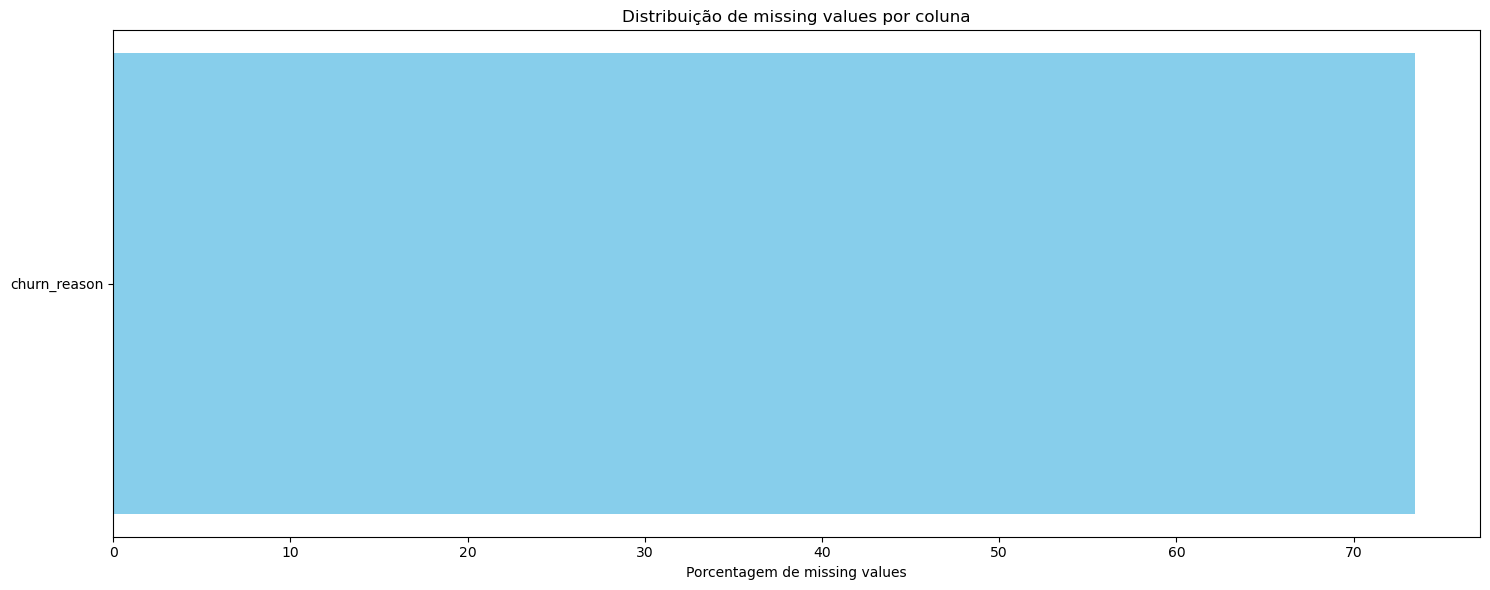

In [22]:
## Análise de missing values
print("===== Missing values =====")

missing_values = pd.DataFrame({
    'Coluna': df.columns,
    'Missing_count': df.isnull().sum(),
    'Missing_Percentage':(df.isnull().sum()/len(df)*100).round(2)
})

missing_values = missing_values[missing_values['Missing_count']>0].sort_values(
    by='Missing_Percentage', ascending=False
)

if len(missing_values) > 0:
    print(missing_values)

# Visualização dos missing values
    plt.figure(figsize=(15,6))
    plt.barh(missing_values['Coluna'], missing_values['Missing_Percentage'], color='skyblue')
    plt.xlabel('Porcentagem de missing values')
    plt.title('Distribuição de missing values por coluna')
    plt.tight_layout()
    plt.show()
else:
    print('Nenhum missing value detectado')

# 4. Análise da variável target

### 4.1 Entendimento da distribuição da variável alvo e o balanceamento de classes

==== Distribuição da variável target
Contagem: 
target
0    5174
1    1869
Name: count, dtype: int64

Percentual: 
cliente churn (0): 73.46%
cliente nao churn (1): 26.54%


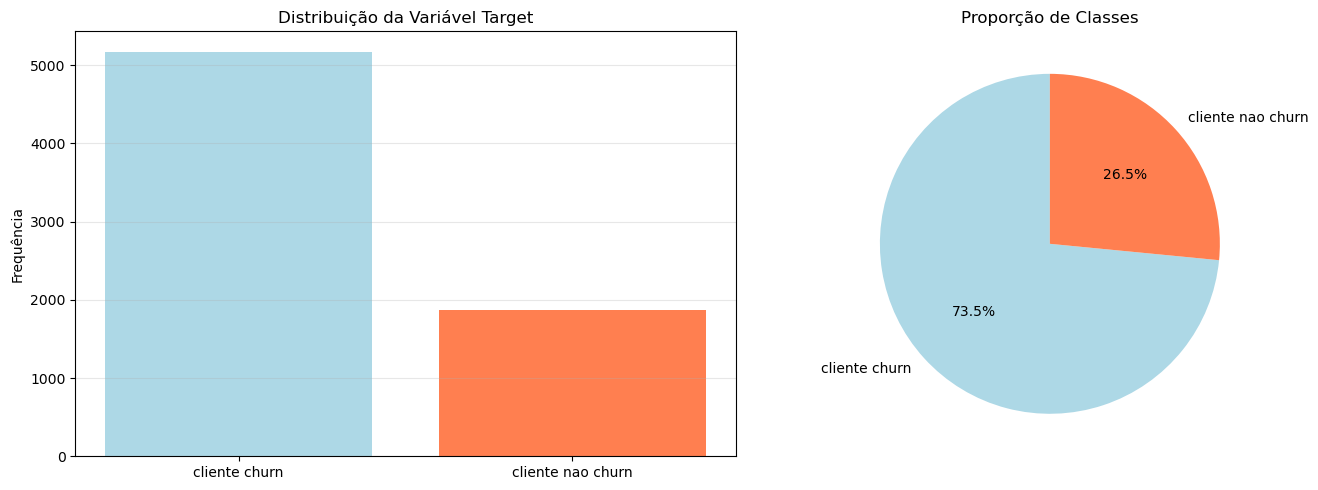


Ratio de balanceamento: 0.36
⚠️ Dataset desbalanceado! Considere usar técnicas como SMOTE ou class_weight.


In [23]:
df.rename(columns={'churn_value': 'target'}, inplace=True)

df['target'] = (df['target'] > 0).astype(int)

print("==== Distribuição da variável target")

target_counts = df['target'].value_counts()
target_percentages = df['target'].value_counts(normalize=True) * 100


print("Contagem: ")
print(target_counts)
print("\nPercentual: ")

for idx, pct in target_percentages.items():
    label = "cliente churn" if idx == 0 else "cliente nao churn"
    print(f"{label} ({idx}): {pct:.2f}%")

# Visualização
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico de barras
axes[0].bar(['cliente churn', 'cliente nao churn'], target_counts.values, color=['lightblue', 'coral'])
axes[0].set_ylabel('Frequência')
axes[0].set_title('Distribuição da Variável Target')
axes[0].grid(axis='y', alpha=0.3)

# Gráfico de pizza
axes[1].pie(target_counts.values, labels=['cliente churn', 'cliente nao churn'], 
            autopct='%1.1f%%', colors=['lightblue', 'coral'], startangle=90)
axes[1].set_title('Proporção de Classes')

plt.tight_layout()
plt.show()

# Verificar se há desbalanceamento
ratio = target_counts.min() / target_counts.max()
print(f"\nRatio de balanceamento: {ratio:.2f}")
if ratio < 0.5:
    print("⚠️ Dataset desbalanceado! Considere usar técnicas como SMOTE ou class_weight.")
else:
    print("✓ Dataset razoavelmente balanceado.")



### 4.2 Análise de distribuição - Gender e Churn

Churn por Gênero:target         0         1
gender                    
Female  0.730791  0.269209
Male    0.738397  0.261603


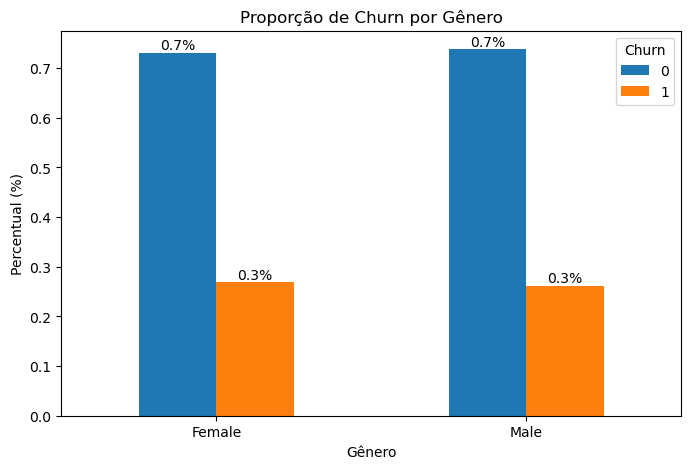

In [24]:
churn_gender = pd.crosstab(df['gender'], df['target'], normalize='index')

print(F"Churn por Gênero:{churn_gender}")
ax = churn_gender.plot(kind='bar', figsize=(8,5))

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%')

plt.title('Proporção de Churn por Gênero')
plt.ylabel('Percentual (%)')
plt.xlabel('Gênero')
plt.xticks(rotation=0)
plt.legend(title='Churn')
plt.show()


### 4.3 Análise de distribuição - City e Churn

Churn por top 5 cidades com mais churn: target                 0          1
city                               
Los Angeles    70.491803  29.508197
Sacramento     75.925926  24.074074
San Diego      66.666667  33.333333
San Francisco  70.192308  29.807692
San Jose       74.107143  25.892857


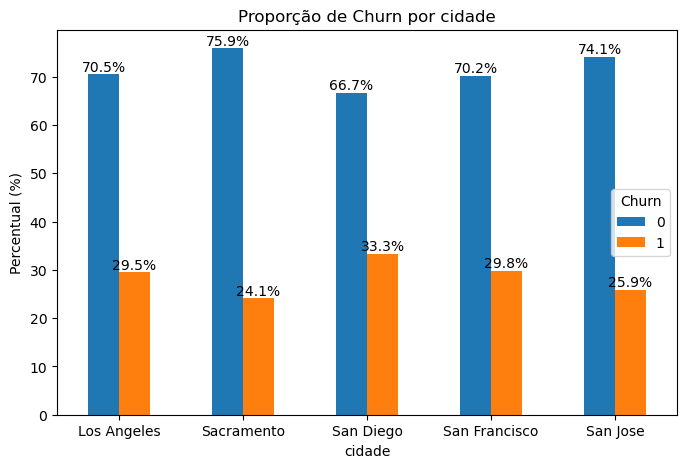

In [25]:
top_cities = df['city'].value_counts().head(5).index
df_top = df[df['city'].isin(top_cities)]

churn_city = pd.crosstab(df_top['city'], df_top['target'], normalize='index') * 100

print(F"Churn por top 5 cidades com mais churn: {churn_city}")
ax = churn_city.plot(kind='bar', figsize=(8,5))

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%')

plt.title('Proporção de Churn por cidade')
plt.ylabel('Percentual (%)')
plt.xlabel('cidade')
plt.xticks(rotation=0)
plt.legend(title='Churn')
plt.show()

### 4.3 Análise de distribuição - Contract e Churn

Churn por tipo contrato:target         0         1
gender                    
Female  0.730791  0.269209
Male    0.738397  0.261603


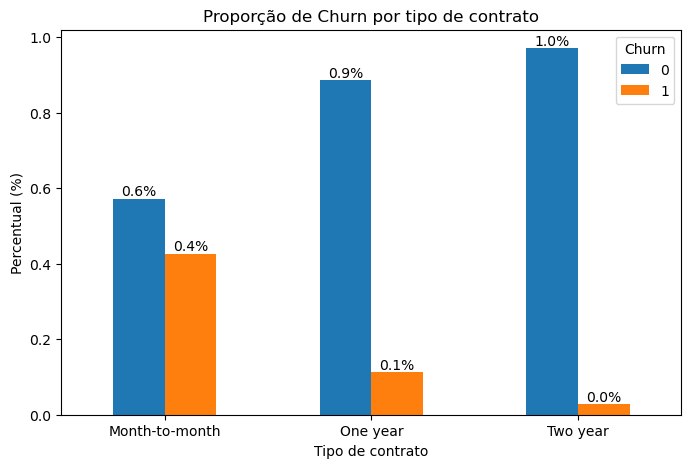

In [26]:
churn_contract = pd.crosstab(df['contract'], df['target'], normalize='index')

print(F"Churn por tipo contrato:{churn_gender}")
ax = churn_contract.plot(kind='bar', figsize=(8,5))

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%')

plt.title('Proporção de Churn por tipo de contrato')
plt.ylabel('Percentual (%)')
plt.xlabel('Tipo de contrato')
plt.xticks(rotation=0)
plt.legend(title='Churn')
plt.show()

### 4.4 Análise de distribuição - Tech Support e Churn

Churn por support:target                      0         1
tech_support                           
No                   0.583645  0.416355
No internet service  0.925950  0.074050
Yes                  0.848337  0.151663


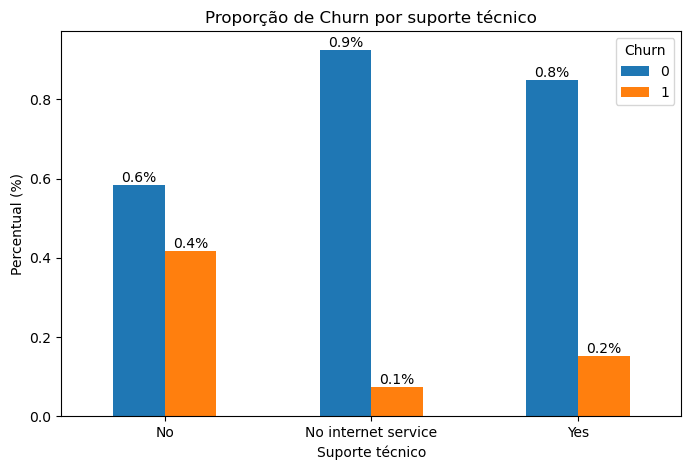

In [27]:
churn_support = pd.crosstab(df['tech_support'], df['target'], normalize='index')

print(F"Churn por support:{churn_support}")
ax = churn_support.plot(kind='bar', figsize=(8,5))

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%')

plt.title('Proporção de Churn por suporte técnico')
plt.ylabel('Percentual (%)')
plt.xlabel('Suporte técnico')
plt.xticks(rotation=0)
plt.legend(title='Churn')
plt.show()

In [28]:
df.head()

,customer_id,count,country,state,city,zip_code,lat_long,latitude,longitude,gender,...,contract,paperless_billing,payment_method,monthly_charges,total_charges,churn_label,target,churn_score,cltv,churn_reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


# Analise de Outlier

C:\Users\lara-\AppData\Local\Temp\ipykernel_22160\3339921452.py:15: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  col_zscore = np.abs(stats.zscore(df[col].dropna()))


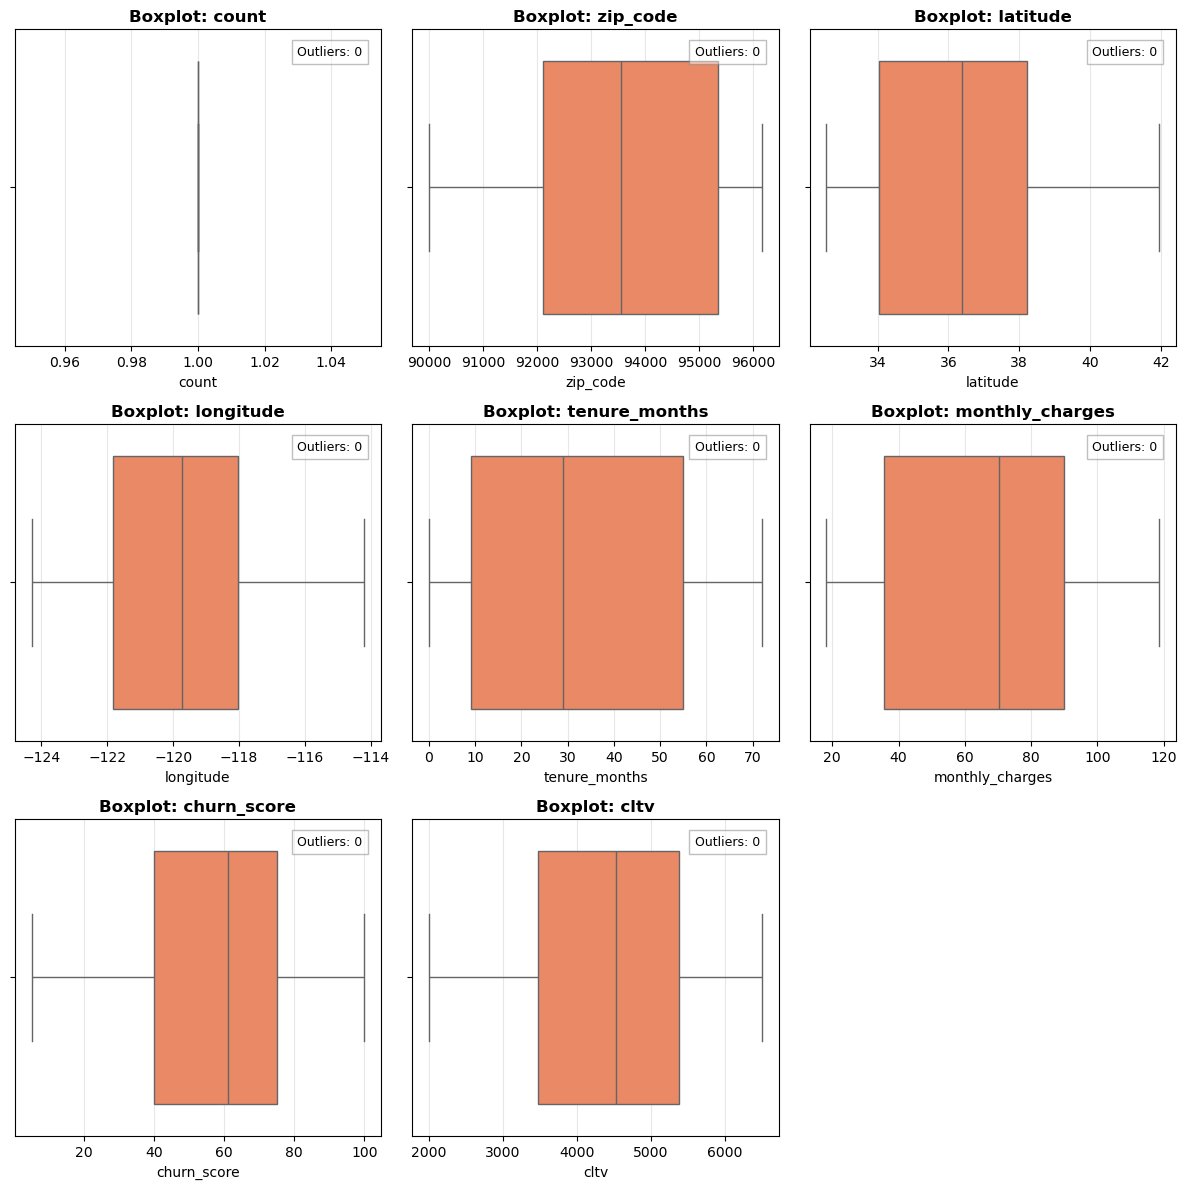

In [29]:
numeric_cols = df.select_dtypes(include=[np.number]).columns
numeric_cols = numeric_cols.drop(['target'])

n = len(numeric_cols)
ncols = 3
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(12, 4 * nrows))
axes = axes.ravel()

for idx, col in enumerate(numeric_cols):
    sns.boxplot(x=df[col], ax=axes[idx], color='coral')
    axes[idx].set_title(f'Boxplot: {col}', fontweight='bold')
    axes[idx].set_xlabel(col)
    axes[idx].grid(axis='x', alpha=0.3)
    col_zscore = np.abs(stats.zscore(df[col].dropna()))
    outlier_count = (col_zscore > 3).sum()
    axes[idx].text(0.95, 0.95, f'Outliers: {outlier_count}', 
                   transform=axes[idx].transAxes, fontsize=9,
                   verticalalignment='top', horizontalalignment='right',
                   bbox=dict(facecolor='white', alpha=0.5, edgecolor='gray'))

for ax in axes[n:]:
    fig.delaxes(ax)

plt.tight_layout()
plt.show()


# Analise de distribuição

=== ANÁLISE DE ASSIMETRIA (SKEWNESS) E CURTOSE ===

         Coluna  Skewness  Kurtosis Interpretação
          count     0.000     0.000        Normal
       zip_code    -0.251    -1.154        Normal
       latitude     0.304    -1.136        Normal
      longitude    -0.041    -1.136        Normal
  tenure_months     0.240    -1.387        Normal
monthly_charges    -0.221    -1.257        Normal
    churn_score    -0.090    -1.006        Normal
           cltv    -0.312    -0.934        Normal


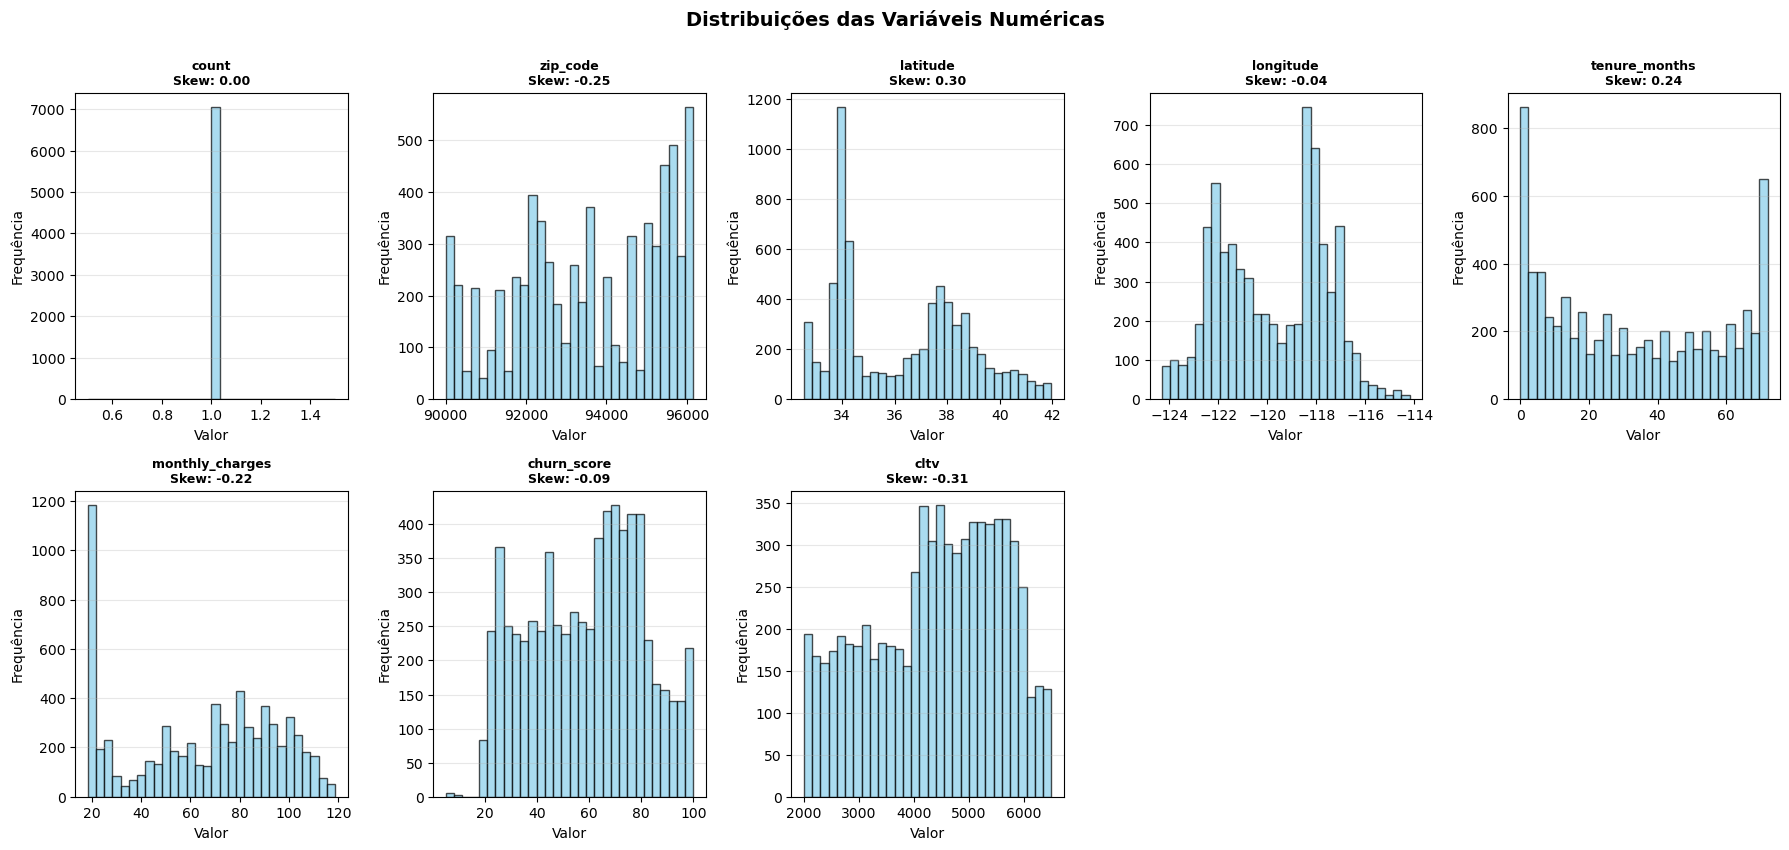

In [30]:
# Análise de distribuições
print("=== ANÁLISE DE ASSIMETRIA (SKEWNESS) E CURTOSE ===\n")

distribution_stats = []
for col in numeric_cols:
    skewness = df[col].skew()
    kurtosis = df[col].kurtosis()
    distribution_stats.append({
        'Coluna': col,
        'Skewness': round(skewness, 3),
        'Kurtosis': round(kurtosis, 3),
        'Interpretação': 'Normal' if abs(skewness) < 0.5 else ('Assimétrica à direita' if skewness > 0 else 'Assimétrica à esquerda')
    })

dist_df = pd.DataFrame(distribution_stats)
print(dist_df.to_string(index=False))

# Visualizar distribuições
fig, axes = plt.subplots(3, 5, figsize=(18, 12))
axes = axes.ravel()

for idx, col in enumerate(numeric_cols):
    if idx < len(axes):
        axes[idx].hist(df[col].dropna(), bins=30, color='skyblue', edgecolor='black', alpha=0.7)
        axes[idx].set_title(f'{col}\nSkew: {df[col].skew():.2f}', fontsize=9, fontweight='bold')
        axes[idx].set_xlabel('Valor')
        axes[idx].set_ylabel('Frequência')
        axes[idx].grid(axis='y', alpha=0.3)

# Remover subplots vazios
for idx in range(len(numeric_cols), len(axes)):
    fig.delaxes(axes[idx])

plt.suptitle('Distribuições das Variáveis Numéricas', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

# Analise de correlações

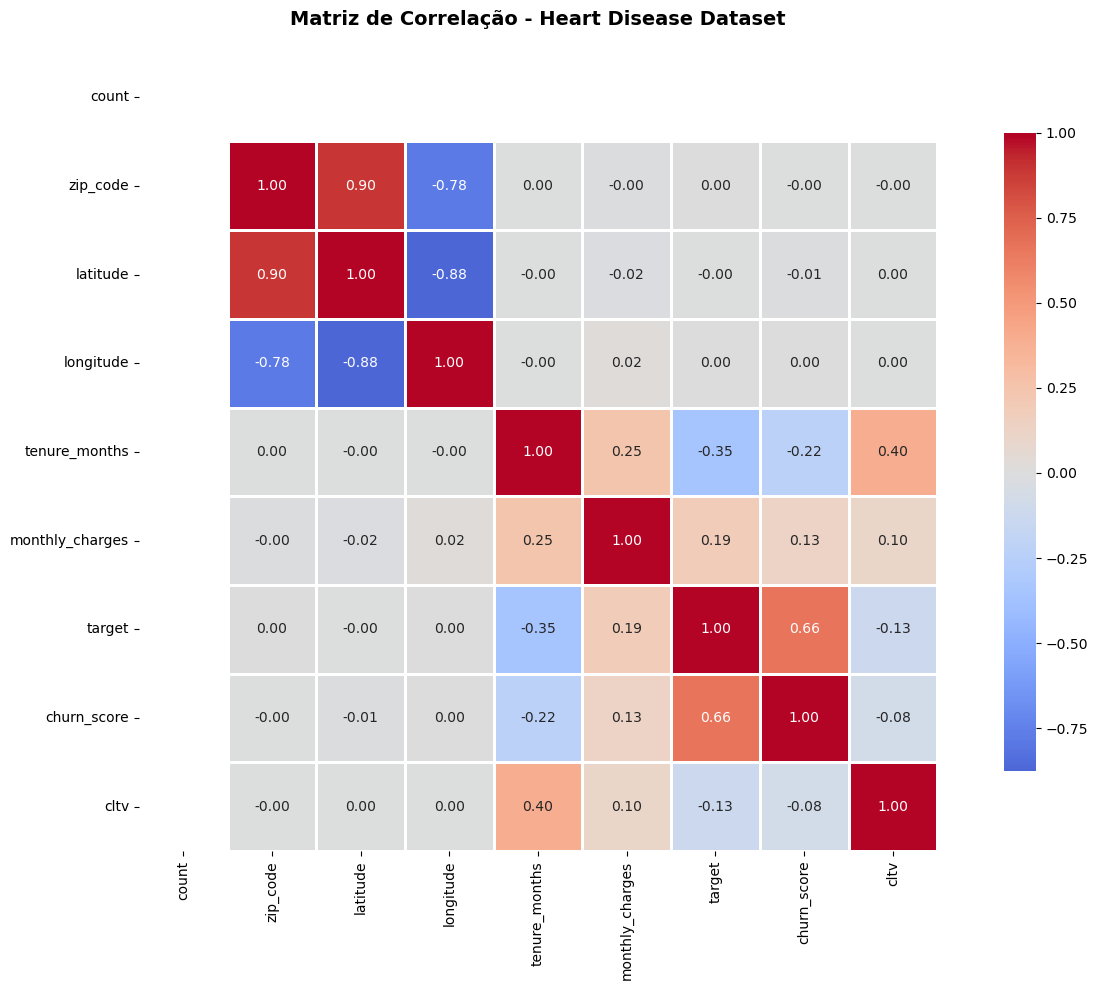

=== CORRELAÇÕES COM A VARIÁVEL TARGET ===

target             1.000000
churn_score        0.664897
monthly_charges    0.193356
longitude          0.004594
zip_code           0.003346
latitude          -0.003384
cltv              -0.127463
tenure_months     -0.352229
count                   NaN
Name: target, dtype: float64

=== MULTICOLINEARIDADE (Correlação entre features) ===
Pares de features com correlação > 0.7:

Feature 1 Feature 2  Correlação
 zip_code  latitude       0.896
 zip_code longitude      -0.784
 latitude longitude      -0.877

⚠️ Alta correlação entre features pode causar multicolinearidade!


In [31]:
# Matriz de correlação apenas para colunas numéricas
corr_numeric = df.select_dtypes(include=[np.number]).corr()

# Visualizar matriz de correlação
plt.figure(figsize=(14, 10))
sns.heatmap(corr_numeric, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Matriz de Correlação - Heart Disease Dataset', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# Identificar correlações fortes com o target
print("=== CORRELAÇÕES COM A VARIÁVEL TARGET ===\n")
target_corr = corr_numeric['target'].sort_values(ascending=False)
print(target_corr)

# Identificar pares de features com alta correlação (possível multicolinearidade)
print("\n=== MULTICOLINEARIDADE (Correlação entre features) ===")
print("Pares de features com correlação > 0.7:\n")

high_corr_pairs = []
for i in range(len(corr_numeric.columns)):
    for j in range(i+1, len(corr_numeric.columns)):
        if abs(corr_numeric.iloc[i, j]) > 0.7 and corr_numeric.columns[i] != 'target' and corr_numeric.columns[j] != 'target':
            high_corr_pairs.append({
                'Feature 1': corr_numeric.columns[i],
                'Feature 2': corr_numeric.columns[j],
                'Correlação': round(corr_numeric.iloc[i, j], 3)
            })

if len(high_corr_pairs) > 0:
    high_corr_df = pd.DataFrame(high_corr_pairs).sort_values(by='Correlação', ascending=False)
    print(high_corr_df.to_string(index=False))
    print("\n⚠️ Alta correlação entre features pode causar multicolinearidade!")
else:
    print("✓ Nenhuma correlação forte detectada entre features (excluindo target)")

In [ ]:
df.rename(columns={
            'CustomerID': 'customer_id',
            'Count': 'count',	
            'Country': 'country',	
            'State': 'state',
            'City': 'city',
            'Zip Code': 'zip_code',
            'Lat Long': 'lat_long',
            'Latitude': 'latitude',
            'Longitude': 'longitude',	
            'Gender': 'gender',
            'Senior Citizen': 'senior_citizen',
            'Partner': 'partner',	
            'Dependents': 'dependents',	
            'Tenure Months': 'tenure_months',	
            'Phone Service': 'phone_service',	
            'Multiple Lines': 'multiple_lines',	
            'Internet Service': 'internet_service',	
            'Online Security': 'online_security',	
            'Online Backup': 'online_backup',	
            'Device Protection': 'device_protection',	
            'Tech Support': 'tech_support',	
            'Streaming TV': 'streaming_tv',	
            'Streaming Movies': 'streaming_movies',	
            'Contract': 'contract',	
            'Paperless Billing': 'paperless_billing',	
            'Payment Method': 'payment_method',
            'Monthly Charges': 'monthly_charges',	
            'Total Charges': 'total_charges',	
            'Churn Label': 'churn_label',	
            'Churn Value': 'churn_value',	
            'Churn Score': 'churn_score',	
            'CLTV': 'cltv',	
            'Churn Reason': 'churn_reason'},
            inplace=True
)

In [ ]:
print("=== TRATAMENTO DE MISSING VALUES ===\n")

# Copiar o dataframe original para preservar os dados
df_clean = df.copy()

# Imputação para variáveis categóricas: moda
cat_missing = ['churn_reason']

for col in cat_missing:
    if col in df_clean.columns:
        mode = df_clean[col].mode()[0]
        df_clean[col].fillna(mode, inplace=True)
        print(f"{col}: imputado com moda ('{mode}')")

print("\n✓ Tratamento de missing values concluído!")
print(f"Shape após imputação: {df_clean.shape}")
print("Valores ausentes restantes por coluna:")
print(df_clean.isnull().sum())

In [ ]:
# Convertendo 'total_charges' para numérico e preenchendo NaN com a média
df_model = df_clean.drop(columns=['customer_id', 'zip_code', 'latitude', 'longitude', 'churn_label', 'churn_score', 'cltv'])    
df_model['total_charges'] = pd.to_numeric(df_clean['total_charges'], errors='coerce')
df_model['total_charges'] = df_model['total_charges'].fillna(df_model['total_charges'].mean())

df_model.describe()

In [ ]:
df_model.to_parquet('../data/processed/dataset_tratado.parquet', index=False)